In [3]:
#back propagation with batch gradient descent
import numpy as np
import matplotlib.pyplot as plt


In [4]:
# XOR Dataset
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([[0],
              [1],
              [1],
              [0]])


In [5]:
np.random.seed(1) #same random numbers are generated every time the program runs

W1 = np.random.rand(2,2)      # 2 Input neurons -> 2 Hidden neurons
b1 = np.zeros((1,2))

W2 = np.random.rand(2,1)      # 2 Hidden neurons -> Output neuron
b2 = np.zeros((1,1))

learning_rate = 0.5
epochs = 5000

loss_list = []


In [6]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

In [7]:
for epoch in range(epochs):
    # -------- Forward Propagation --------
    hidden = sigmoid(np.dot(X, W1) + b1)
    output = sigmoid(np.dot(hidden, W2) + b2)

    # -------- Loss Calculation --------
    loss = np.mean((y - output) ** 2)
    loss_list.append(loss)

    # -------- Backpropagation --------
    output_error = y - output
    output_delta = output_error * sigmoid_derivative(output)

    hidden_error = np.dot(output_delta, W2.T)
    hidden_delta = hidden_error * sigmoid_derivative(hidden)

    # -------- Update Weights --------
    W2 += learning_rate * np.dot(hidden.T, output_delta)
    b2 += learning_rate * np.sum(output_delta, axis=0, keepdims=True)

    W1 += learning_rate * np.dot(X.T, hidden_delta)
    b1 += learning_rate * np.sum(hidden_delta, axis=0, keepdims=True)

    # Display only first epoch details
    if epoch == 0:
        print("----------- FIRST EPOCH -----------")

        print("\nHidden Layer Output")
        print(np.round(hidden,3))

        print("\nOutput Layer Output")
        print(np.round(output,3))

        print("\nLoss")
        print(round(loss,5))

    # Display loss after every 500 epochs
    if (epoch + 1) % 500 == 0:
        print("Epoch:", epoch + 1,
              " Loss:", round(loss,5))


----------- FIRST EPOCH -----------

Hidden Layer Output
[[0.5   0.5  ]
 [0.5   0.575]
 [0.603 0.673]
 [0.603 0.735]]

Output Layer Output
[[0.53 ]
 [0.532]
 [0.538]
 [0.539]]

Loss
0.25113
Epoch: 500  Loss: 0.24808
Epoch: 1000  Loss: 0.15139
Epoch: 1500  Loss: 0.01094
Epoch: 2000  Loss: 0.00413
Epoch: 2500  Loss: 0.00245
Epoch: 3000  Loss: 0.00172
Epoch: 3500  Loss: 0.00132
Epoch: 4000  Loss: 0.00106
Epoch: 4500  Loss: 0.00089
Epoch: 5000  Loss: 0.00076



----------- FINAL PREDICTION -----------
Input: [0 0]  Target: 0  Prediction: 0
Input: [0 1]  Target: 1  Prediction: 1
Input: [1 0]  Target: 1  Prediction: 1
Input: [1 1]  Target: 0  Prediction: 0

Accuracy = 100.0 %


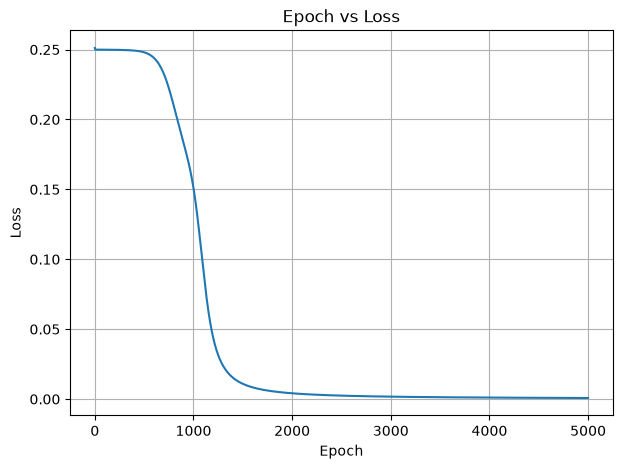

In [8]:
print("\n----------- FINAL PREDICTION -----------")

predicted = (output >= 0.5).astype(int)

for i in range(len(X)):
    print("Input:", X[i],
          " Target:", y[i][0],
          " Prediction:", predicted[i][0])

accuracy = np.mean(predicted == y)

print("\nAccuracy =", round(accuracy * 100,2), "%")

plt.figure(figsize=(7,5))
plt.plot(loss_list)
plt.title("Epoch vs Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()